## 1. Setup & Data Loading

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import re
import string
import random

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
from sklearn.preprocessing import normalize
from gensim.models import Word2Vec

sns.set_theme(style="whitegrid")
%matplotlib inline

In [2]:
CSV_PATH  = "data/amazon_products.csv"
CATS_PATH = "data/amazon_categories.csv"

df   = pd.read_csv(CSV_PATH)
cats = pd.read_csv(CATS_PATH).rename(columns={"id": "category_id", "category_name": "categoryName"})
df   = df.merge(cats, on="category_id", how="left")
df["categoryName"] = df["categoryName"].fillna("Unknown")

products_loaded_count = len(df)

print(f"Shape: {df.shape}")
print("\nColumn names and dtypes:")
print(df.dtypes)

Shape: (1426337, 12)

Column names and dtypes:
asin                     str
title                    str
imgUrl                   str
productURL               str
stars                float64
reviews                int64
price                float64
listPrice            float64
category_id            int64
isBestSeller            bool
boughtInLastMonth      int64
categoryName             str
dtype: object


In [3]:
df.head(3)

,asin,title,imgUrl,productURL,stars,reviews,price,listPrice,category_id,isBestSeller,boughtInLastMonth,categoryName
0,B014TMV5YE,"Sion Softside Expandable Roller Luggage, Black...",https://m.media-amazon.com/images/I/815dLQKYIY...,https://www.amazon.com/dp/B014TMV5YE,4.5,0,139.99,0.00,104,False,2000,Suitcases
1,B07GDLCQXV,Luggage Sets Expandable PC+ABS Durable Suitcas...,https://m.media-amazon.com/images/I/81bQlm7vf6...,https://www.amazon.com/dp/B07GDLCQXV,4.5,0,169.99,209.99,104,False,1000,Suitcases
2,B07XSCCZYG,Platinum Elite Softside Expandable Checked Lug...,https://m.media-amazon.com/images/I/71EA35zvJB...,https://www.amazon.com/dp/B07XSCCZYG,4.6,0,365.49,429.99,104,False,300,Suitcases


In [4]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:


asin                 0
title                1
imgUrl               0
productURL           0
stars                0
reviews              0
price                0
listPrice            0
category_id          0
isBestSeller         0
boughtInLastMonth    0
categoryName         0
dtype: int64


## 2. Exploratory Data Analysis

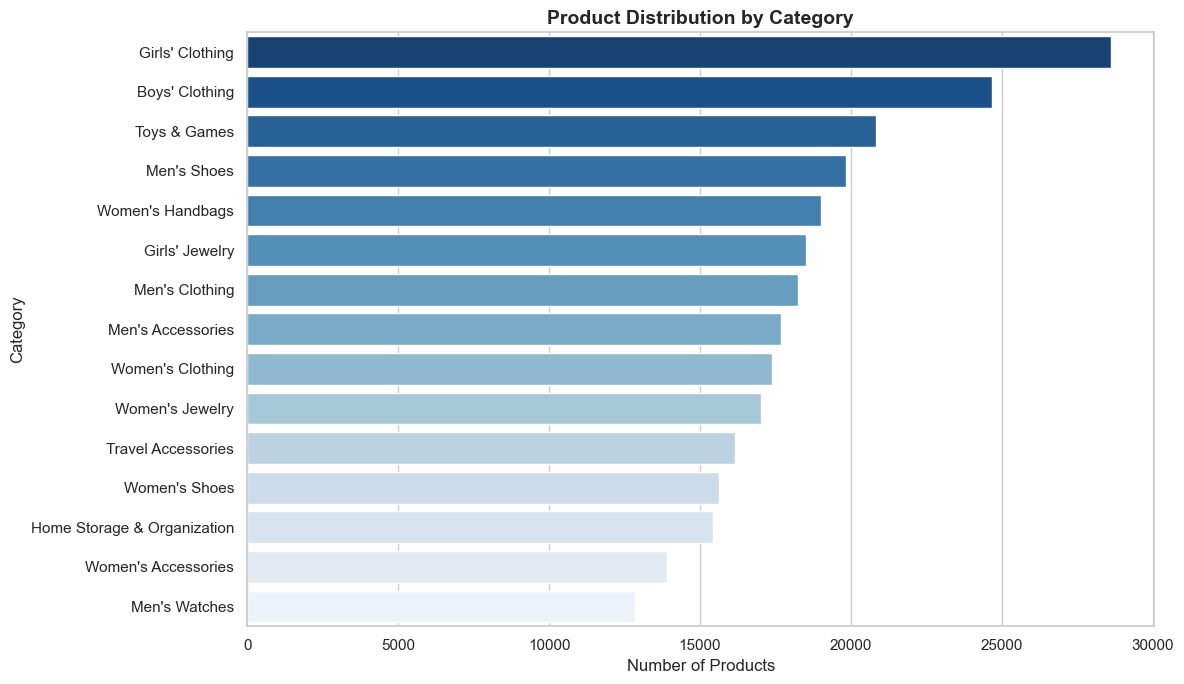

In [5]:
top_cats = df["categoryName"].value_counts().head(15).reset_index()
top_cats.columns = ["category", "count"]

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=top_cats, x="count", y="category", hue="category", ax=ax,
            palette="Blues_r", legend=False)
ax.set_title("Product Distribution by Category", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Products")
ax.set_ylabel("Category")
plt.tight_layout()
plt.show()

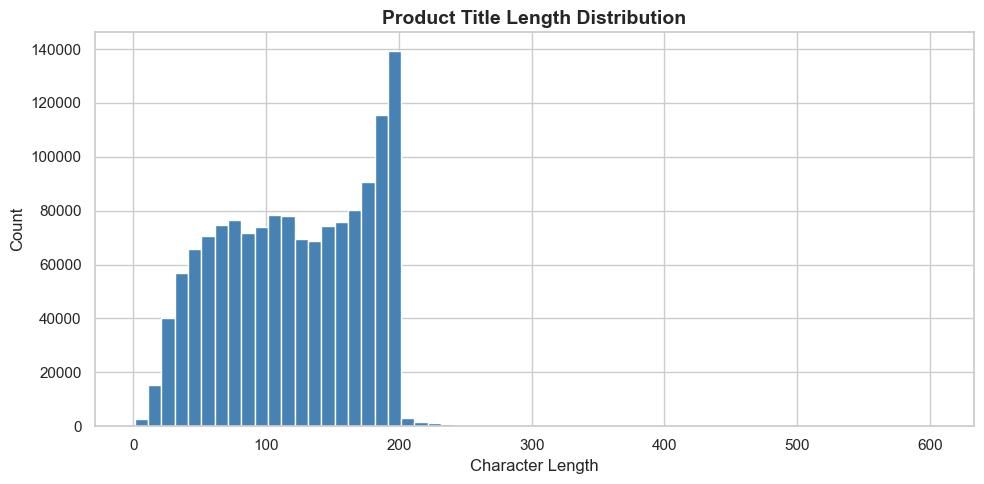

In [6]:
title_lengths = df["title"].dropna().str.len()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(title_lengths, bins=60, color="steelblue", edgecolor="white")
ax.set_title("Product Title Length Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Character Length")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

In [7]:
unique_categories = df["categoryName"].nunique()
missing_title_pct = df["title"].isnull().mean() * 100

print(f"Total products    : {products_loaded_count:,}")
print(f"Unique categories : {unique_categories}")
print(f"Missing titles    : {missing_title_pct:.2f}%")

Total products    : 1,426,337
Unique categories : 248
Missing titles    : 0.00%


## 3. Text Preprocessing

In [8]:
_PUNCT_DIGITS = re.compile(f"[{re.escape(string.punctuation)}0-9]")
_SPACES = re.compile(r"\s+")


def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = _PUNCT_DIGITS.sub(" ", text)
    text = _SPACES.sub(" ", text).strip()
    return text

In [9]:
df["clean_text"] = df["title"].apply(clean_text)

print("Sample clean_text values:")
print(df[["title", "clean_text"]].head(3).to_string(index=False))

Sample clean_text values:
                                                                                                                                        title                                                                                                                          clean_text
                                                                        Sion Softside Expandable Roller Luggage, Black, Checked-Large 29-Inch                                                                    sion softside expandable roller luggage black checked large inch
                                                                  Luggage Sets Expandable PC+ABS Durable Suitcase Double Wheels TSA Lock Blue                                                         luggage sets expandable pc abs durable suitcase double wheels tsa lock blue
Platinum Elite Softside Expandable Checked Luggage, 8 Wheel Spinner Suitcase, TSA Lock, Men and Women, True Navy Blue, Checked Medium 25-Inch platinum e

In [10]:
df = df[df["clean_text"].str.len() >= 3].reset_index(drop=True)
print(f"Dataset shape after cleaning: {df.shape}")

Dataset shape after cleaning: (1426246, 13)


## 4. TF-IDF Recommender

In [11]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df["clean_text"])
print(f"TF-IDF matrix shape : {tfidf_matrix.shape}")
print(f"Non-zero elements   : {tfidf_matrix.nnz:,}")

TF-IDF matrix shape : (1426246, 50000)
Non-zero elements   : 30,628,203


In [12]:
category_index: dict[str, list[int]] = {}
for row_idx, cat in enumerate(df["categoryName"]):
    category_index.setdefault(cat, []).append(row_idx)

print(f"Category index built: {len(category_index)} categories")
for cat, idxs in sorted(category_index.items(), key=lambda x: -len(x[1]))[:5]:
    print(f"  {cat}: {len(idxs):,} products")

Category index built: 248 categories
  Girls' Clothing: 28,619 products
  Boys' Clothing: 24,659 products
  Toys & Games: 20,846 products
  Men's Shoes: 19,817 products
  Women's Handbags: 18,991 products


In [13]:
def get_tfidf_recommendations(product_idx: int, top_k: int = 10) -> pd.DataFrame:
    category = df.at[product_idx, "categoryName"]
    cat_indices = category_index[category]

    query_vec = tfidf_matrix[product_idx]
    cat_matrix = tfidf_matrix[cat_indices]

    scores = linear_kernel(query_vec, cat_matrix).flatten()

    sorted_positions = np.argsort(scores)[::-1]
    results = []
    for pos in sorted_positions:
        idx = cat_indices[pos]
        if idx == product_idx:
            continue
        results.append({
            "title": df.at[idx, "title"],
            "category": category,
            "similarity_score": round(float(scores[pos]), 4),
        })
        if len(results) >= top_k:
            break

    return pd.DataFrame(results)

## 5. Word2Vec Recommender

In [14]:
tokenized_titles: list[list[str]] = [text.split() for text in df["clean_text"]]

w2v_model = Word2Vec(
    sentences=tokenized_titles,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=5,
    seed=42,
)

print(f"Word2Vec vocabulary size: {len(w2v_model.wv):,}")

Word2Vec vocabulary size: 117,653


In [15]:
def get_doc_vector(tokens: list[str]) -> np.ndarray:
    vecs = [w2v_model.wv[t] for t in tokens if t in w2v_model.wv]
    if not vecs:
        return np.zeros(w2v_model.vector_size)
    return np.mean(vecs, axis=0)

In [16]:
doc_vectors = np.vstack([get_doc_vector(tokens) for tokens in tokenized_titles])
doc_vectors_norm = normalize(doc_vectors)
print(f"Document vector matrix shape: {doc_vectors_norm.shape}")

Document vector matrix shape: (1426246, 100)


In [17]:
def get_w2v_recommendations(product_idx: int, top_k: int = 10) -> pd.DataFrame:
    category = df.at[product_idx, "categoryName"]
    cat_indices = np.array(category_index[category])

    query_vec = doc_vectors_norm[product_idx]
    cat_vecs = doc_vectors_norm[cat_indices]

    scores = cat_vecs @ query_vec

    sorted_positions = np.argsort(scores)[::-1]
    results = []
    for pos in sorted_positions:
        idx = int(cat_indices[pos])
        if idx == product_idx:
            continue
        results.append({
            "title": df.at[idx, "title"],
            "category": category,
            "similarity_score": round(float(scores[pos]), 4),
        })
        if len(results) >= top_k:
            break

    return pd.DataFrame(results)

## 6. Performance Benchmark

In [18]:
N_TRIALS = 50
random.seed(0)
test_indices = random.sample(range(len(df)), 5)


def _bench(fn, indices: list[int], n_trials: int) -> list[float]:
    times_ms = []
    for _ in range(n_trials):
        for idx in indices:
            t0 = time.perf_counter()
            fn(idx)
            times_ms.append((time.perf_counter() - t0) * 1000)
    return times_ms


tfidf_times = _bench(get_tfidf_recommendations, test_indices, N_TRIALS)
w2v_times   = _bench(get_w2v_recommendations,   test_indices, N_TRIALS)

In [19]:
def _print_row(label: str, times: list[float]) -> None:
    arr = np.array(times)
    mean_ms   = arr.mean()
    median_ms = float(np.median(arr))
    p95_ms    = float(np.percentile(arr, 95))
    sub100    = float((arr < 100).mean() * 100)
    print(f"{label:<12} | {mean_ms:>9.2f} | {median_ms:>11.2f} | {p95_ms:>8.2f} | {sub100:>10.1f}%")


header = f"{'Method':<12} | {'Mean (ms)':>9} | {'Median (ms)':>11} | {'P95 (ms)':>8} | {'Sub-100ms %':>11}"
print(header)
print("-" * len(header))
_print_row("TF-IDF",   tfidf_times)
_print_row("Word2Vec", w2v_times)

Method       | Mean (ms) | Median (ms) | P95 (ms) | Sub-100ms %
---------------------------------------------------------------
TF-IDF       |      7.86 |        6.17 |    14.66 |      100.0%
Word2Vec     |      5.29 |        3.50 |    10.92 |      100.0%


## 7. Demo

In [20]:
demo_cats    = list(category_index.keys())[:3]
demo_indices = [category_index[cat][5] for cat in demo_cats]

for product_idx in demo_indices:
    title = df.at[product_idx, "title"]
    cat   = df.at[product_idx, "categoryName"]
    print(f"\nQuery: {title} (Category: {cat})")

    print("--- TF-IDF Top 5 ---")
    for i, row in get_tfidf_recommendations(product_idx, top_k=5).iterrows():
        print(f"  {i + 1}. [{row['similarity_score']:.4f}] {row['title']}")

    print("--- Word2Vec Top 5 ---")
    for i, row in get_w2v_recommendations(product_idx, top_k=5).iterrows():
        print(f"  {i + 1}. [{row['similarity_score']:.4f}] {row['title']}")


Query: Maxlite 5 Softside Expandable Luggage with 4 Spinner Wheels, Lightweight Suitcase, Men and Women, Sapphire Blue, Carry-On 21-Inch (Category: Suitcases)
--- TF-IDF Top 5 ---
  1. [0.7161] Lares Softside Expandable Luggage with Spinner Wheels, Purple, Checked 30-Inch
  2. [0.7161] Lineate DLX Softside Expandable Luggage with Spinner Wheels, Merlot
  3. [0.6855] 28 Inch Luggage with Spinner Wheels Softside Expandable Large Suitcase
  4. [0.6767] 4 Kix Expandable Softside Luggage with Spinner Wheels, Black/Grey, Carry-On 21-Inch
  5. [0.6565] Sky Max 2.0 Softside Expandable Luggage with Spinner Wheels, Blue, Checked-Medium, 24 Inch
--- Word2Vec Top 5 ---
  1. [0.9495] Tourlite Softside Expandable Upright 2 Wheel Luggage, Lightweight Suitcase, Men and Women, Black, Carry-On 22-Inch
  2. [0.9331] Designer Luggage Collection - Expandable 28 Inch Softside Bag for Men & Women - Durable Lightweight Checked Suitcase with 4-Rolling Spinner Wheels (28in, Global Black)
  3. [0.9300] Designer

## 8. Summary

In [21]:
tfidf_arr = np.array(tfidf_times)
w2v_arr   = np.array(w2v_times)

tfidf_median = float(np.median(tfidf_arr))
w2v_median   = float(np.median(w2v_arr))
tfidf_sub100 = float((tfidf_arr < 100).mean() * 100)
w2v_sub100   = float((w2v_arr < 100).mean() * 100)

print("=" * 65)
print(f"{'Dataset':<25} : Amazon Products 2023 (Kaggle)")
print(f"{'Products loaded':<25} : {products_loaded_count:,}")
print(f"{'Products after cleaning':<25} : {len(df):,}")
print(f"{'Categories':<25} : {df['categoryName'].nunique()}")
print(f"{'Text features':<25} : TF-IDF (50K features, bigrams) + Word2Vec (100d, window=5)")
print(f"{'Recommendation':<25} : Category-aware cosine similarity")
print(f"{'TF-IDF latency':<25} : {tfidf_median:.1f} ms median ({tfidf_sub100:.0f}% sub-100ms)")
print(f"{'Word2Vec latency':<25} : {w2v_median:.1f} ms median ({w2v_sub100:.0f}% sub-100ms)")
print("=" * 65)

Dataset                   : Amazon Products 2023 (Kaggle)
Products loaded           : 1,426,337
Products after cleaning   : 1,426,246
Categories                : 248
Text features             : TF-IDF (50K features, bigrams) + Word2Vec (100d, window=5)
Recommendation            : Category-aware cosine similarity
TF-IDF latency            : 6.2 ms median (100% sub-100ms)
Word2Vec latency          : 3.5 ms median (100% sub-100ms)
